# Description

Plot general features of the SNOTEL stations

# Load analysis functions

In [11]:
%run ...../imports.ipynb
%run ...../analysisScripts/snotelAnalysisFunctions.ipynb

# Load data

add choice for loading all stations or just biased corrected stations...

In [12]:
stationBiasDict = loadTempBiasMarker()

In [13]:
rootPath = '..../snotelData/raw/'
stateNames = ['CO','AK','AZ','CA','ID','MT','NM','NV','OR','SD','UT','WA','WY']
metaData = loadStationMetaData()

In [14]:
allStateDict = {}
for stateName in tqdm(stateNames):
    stateFileNames = glob.glob(rootPath + stateName + '/' + '*')
    stateDataAll = [csvToXarray(f) for f in stateFileNames]
    stateDataCleaned = [s for s in stateDataAll if s.BAD_DATA==False]
    allStateDict[stateName] = stateDataCleaned

100%|██████████| 13/13 [00:13<00:00,  1.04s/it]


In [15]:
## Filter stations with the same functions used in other notebooks ##
allStateDict_filtered = filterStations(stateNames,allStateDict)

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 88/89         

# Plot station metrics

Options include:
- "obsMeanWinterTemp"
- "elevation"
- "meanPeakSWE"
- "winterPrcpRate"
- "tau_F"

In [16]:
winterPrcpRateByYearCalled = 0
    # the winterPrcpRateByYear is reused often in the code, save time by tracking if it has already been called

In [17]:
metricChoice = 'meanPeakSWE'

In [19]:
if metricChoice == 'obsMeanWinterTemp':
    dictForPlot = obsMeanWinterTemp(stateNames,allStateDict_filtered)
    metricName = 'meanWinterTemp'
    metricLabel = r'$\degree$C'
    metricTitle = 'November through March mean temperature'
    winterPrcpRateByYearCalled = 0
elif metricChoice == 'elevation':
    dictForPlot = allStateDict_filtered
    metricName = 'elevation_m'
    metricLabel = 'meters'
    metricTitle = 'Station elevation'
    winterPrcpRateByYearCalled = 0
elif metricChoice == 'meanPeakSWE':
    if not winterPrcpRateByYearCalled:
        dictForPlot = winterPrcpRateByYear(stateNames,allStateDict_filtered)
        winterPrcpRateByYearCalled = 1
    metricName = 'peakSWE'
    metricLabel = 'mm'
    metricTitle = 'Mean annual maximum SWE'
elif metricChoice == 'winterPrcpRate':
    if not winterPrcpRateByYearCalled:
        dictForPlot = winterPrcpRateByYear(stateNames,allStateDict_filtered)
        winterPrcpRateByYearCalled = 1
    metricName = 'precipRates'
    metricLabel = 'mm/day'
    metricTitle = 'November through March mean precipitation rate'
elif metricChoice == 'tau_F':
    if not winterPrcpRateByYearCalled:
        dictForPlot = winterPrcpRateByYear(stateNames,allStateDict_filtered)
        winterPrcpRateByYearCalled = 1
    metricName = 'numDaysBelowTThresh_s'
    metricLabel = 'days'
    metricTitle = 'Mean number of days below 0$\degree$C per year'
else:
    print('Bummer, not a valid metric choice!')

['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM']: 3/27         

/tmp/ipykernel_1199/132286664.py:58: RuntimeWarning: invalid value encountered in scalar divide
  P_duringSnow = np.sum(currPInterp[firstSnowInd:indMax])/tMax_tStart_days


['CO', 'AK', 'AZ', 'CA', 'ID', 'MT', 'NM', 'NV', 'OR', 'SD', 'UT', 'WA', 'WY']: 38/39         

Text(0.5, 1.0, 'Mean annual maximum SWE')

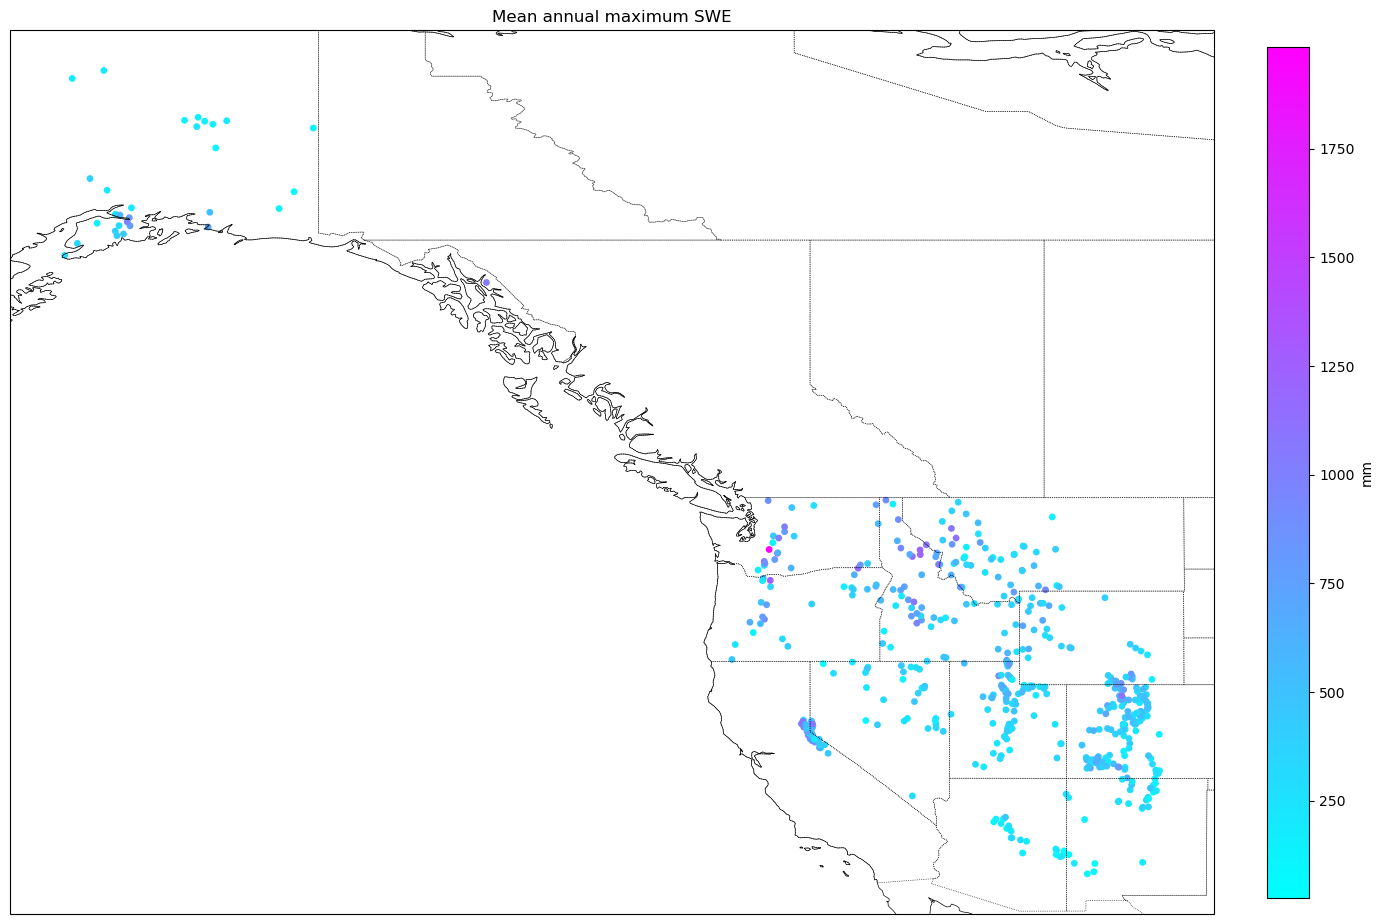

In [20]:
fig = plt.figure(figsize=(17,17))
ax0 = plt.subplot(1,1,1, projection=ccrs.PlateCarree())

# Add coastlines
ax0.coastlines(linewidth=0.5)

# Add U.S. state borders
ax0.add_feature(cfeature.STATES, linestyle=':', edgecolor='black', linewidth=0.5)

lats = np.array([])
lons = np.array([])
metrics = np.array([])

for istate,stateName in enumerate(stateNames):
    stations = dictForPlot[stateName]
    if len(stations)>0:
        for stat in stations:
            lats = np.append(lats,stat.latitude)
            lons = np.append(lons,stat.longitude)
            if metricChoice in ['meanPeakSWE','winterPrcpRate','tau_F']:
                metrics = np.append(metrics, np.nanmean(getattr(stat,metricName)))
            else:
                metrics = np.append(metrics, getattr(stat,metricName))

sc = ax0.scatter(lons,lats,15,c=metrics,cmap='cool')
im_ratio = lons.shape[0]/lats.shape[0]
fig.colorbar(sc, ax=ax0,label=metricLabel,fraction=0.046, pad=0.04,shrink=0.65)
ax0.set_title(metricTitle)

In [21]:
# Save this data for final plot
saveBool = 0
if metricChoice == 'meanPeakSWE' and saveBool == True:
    pathToSave = '...../figureData'
    np.savez(pathToSave + '/figure1MaxSWE.npz', lats=lats, lons=lons, peakSWE=metrics)